In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt 
from imblearn.pipeline import Pipeline as ImbPipeline


# Before start with the model construction
First load the Kaggle's Database 

In [3]:
path = r"C:\Users\Joaquin\Documents\Python\DataBase\creditcard.csv"
df = pd.read_csv(path)

Separete the targe, what is the column "Class" to evade the Dataleaks and use SMOTE to balance classes

In [4]:
target = "Class"
features = [col for col in df.columns if col != target]

y = df[target]
X = df[features]
print(f"target: {y.shape} \nfeatures: {X.shape}")

target: (284807,) 
features: (284807, 30)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.25,
    random_state= 42,
    stratify= y
)
# Compare rates to confirm stratification worked
y_train.mean(), y_test.mean()

(np.float64(0.0017274876524425926), np.float64(0.0017274795651807534))

In [6]:
# Oversample the minority class
smt = SMOTE(
    random_state=42
)
X_train_over, y_train_over = smt.fit_resample(
    X_train,
    y_train
)
y_train_over.value_counts()

Class
0    213236
1    213236
Name: count, dtype: int64

Define a function to extract all metrics of our models

In [9]:
def metrics(
        y_true: pd.Series,
        y_pred: pd.Series,
        y_prob: pd.Series
):
    precision = precision_score(y_true , y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    return {
        "Precision" : precision,
        "Recall" : recall,
        "f1" : f1,
        "ROC AUC" : roc_auc
    }

# Star with the models
First the baseline, this will be our reference model 

In [7]:
# Create baseline
gb_baseline = Pipeline([
    ("baseline_gb" ,GradientBoostingClassifier(
        random_state=42
    ))
])

gb_baseline.fit(X_train_over, y_train_over)


,steps,"[('baseline_gb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1


In [8]:

y_pred_gb0 = gb_baseline.predict(X_test)
y_prob_gb0 = gb_baseline.predict_proba(X_test)[:,1]
gb0_metrics = metrics(y_test, y_pred_gb0, y_prob_gb0)
gb0_metrics

{'Precision': 0.19744058500914077,
 'Recall': 0.8780487804878049,
 'f1': 0.32238805970149254,
 'ROC AUC': 0.9759666245630507}

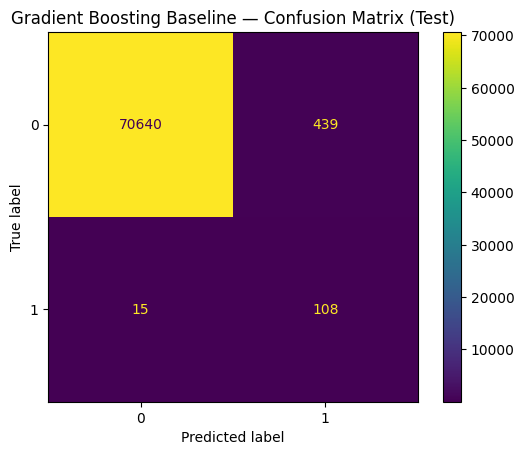

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,        
    y_pred_gb0,     
    values_format="d"
)
plt.title( "Gradient Boosting Baseline — Confusion Matrix (Test)")
plt.show()

Second model, a Random Forest without probability adjusting

In [7]:
# Random Forest Model
rf_model = Pipeline([
    ("Forest", RandomForestClassifier(random_state= 42)
     )
])
rf_model.fit(X_train_over, y_train_over)

,steps,"[('Forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


In [10]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
rf_metrics = metrics(y_test, y_pred_rf, y_prob_rf)
rf_metrics

{'Precision': 0.8461538461538461,
 'Recall': 0.8048780487804879,
 'f1': 0.825,
 'ROC AUC': 0.9652752685463799}

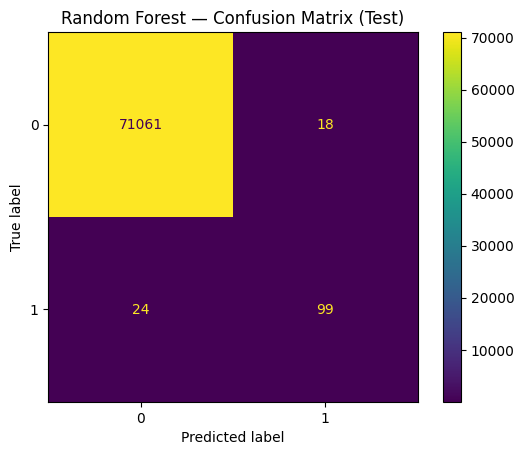

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,        
    y_pred_rf,     
    values_format="d"
)
plt.title( "Random Forest — Confusion Matrix (Test)")
plt.show()

adjusting probability of Random Forest model and calculating metrics

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold optimum : {best_threshold:.4f}")


Umbral (Threshold) óptimo : 0.6800


In [ ]:

y_pred_rf_prob = (y_prob_rf >= best_threshold).astype(int)
rf_prob_metrics = metrics(y_test, y_pred_rf_prob, y_prob_rf)
rf_prob_metrics

{'Precision': 0.9320388349514563,
 'Recall': 0.7804878048780488,
 'f1': 0.8495575221238938,
 'ROC AUC': 0.9652752685463799}

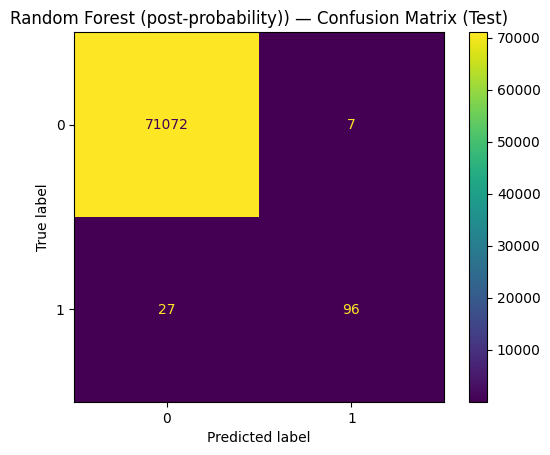

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,        
    y_pred_rf_prob,     
    values_format="d"
)
plt.title( "Random Forest (post-probability)) — Confusion Matrix (Test)")
plt.show()

Tuned Gradient Boosting using a small, readable grid

In [ ]:

gb_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    "gb__n_estimators": [200, 300],
    "gb__learning_rate": [0.05, 0.1],
    "gb__max_depth": [2, 3],
    "gb__subsample": [1.0, 0.8],
}

grid = GridSearchCV(
    gb_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=4,     
    n_jobs=-1 
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'gb__learning_rate': 0.1,
  'gb__max_depth': 3,
  'gb__n_estimators': 300,
  'gb__subsample': 0.8},
 np.float64(0.641460644785614))

In [14]:
gb_grid = grid.best_estimator_

y_pred_gb = gb_grid.predict(X_test)
y_proba_gb = pd.Series(gb_grid.predict_proba(X_test)[:, 1])

gb_metrics = metrics(y_test, y_pred_gb, y_proba_gb)
gb_metrics

{'Precision': 0.41015625,
 'Recall': 0.8536585365853658,
 'f1': 0.554089709762533,
 'ROC AUC': 0.9706206891976487}

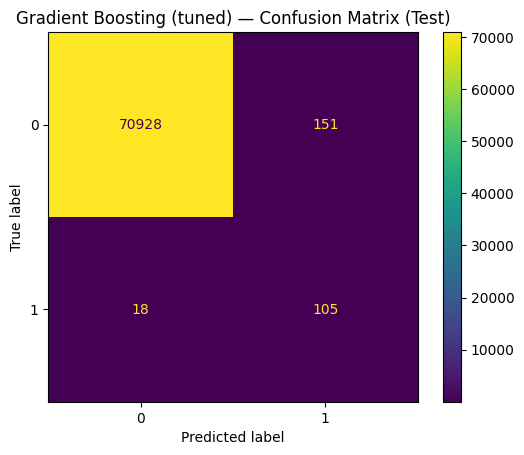

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,        
    y_pred_gb,     
    values_format="d"
)
plt.title( "Gradient Boosting (tuned) — Confusion Matrix (Test)")
plt.show()

adjusting probability of Gradient Boosting tuned and calculating metrics

In [ ]:
y_proba_grid = grid.predict_proba(X_test)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_grid)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Umbral (Threshold) óptimo : {best_threshold:.4f}")

Umbral (Threshold) óptimo : 0.9691
Precisión esperada        : 0.8130
Recall esperado           : 0.8130
F1-Score máximo           : 0.8130


In [ ]:
y_pred_prob = (y_proba_grid >= best_threshold).astype(int)
gb_prob_metrics = metrics(y_test, y_pred_prob, y_proba_gb)
gb_prob_metrics

{'Precision': 0.8130081300813008,
 'Recall': 0.8130081300813008,
 'f1': 0.8130081300813008,
 'ROC AUC': 0.9706206891976487}

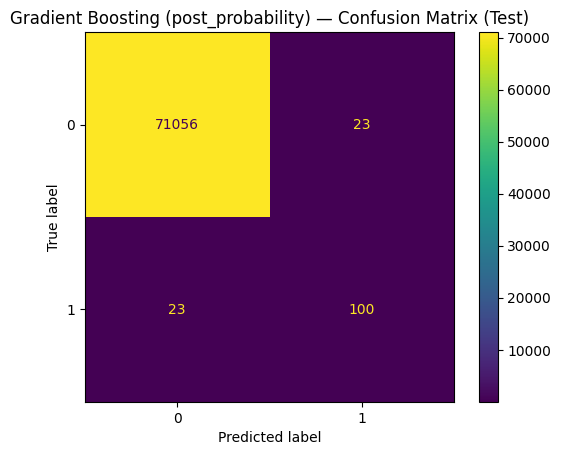

In [18]:

ConfusionMatrixDisplay.from_predictions(
    y_test,        
    y_pred_prob,     
    values_format="d"
)
plt.title( "Gradient Boosting (post_probability) — Confusion Matrix (Test)")
plt.show()

# Comunicating the result

In [ ]:
comparison = pd.DataFrame(
    [
        {"model": "Random Forest", **rf_metrics},
        {"model": "Random Forest (post-probabilty)", **rf_prob_metrics},         
        {"model": "GradBoost (baseline)", **gb0_metrics}, 
        {"model": "GradBoost (pre-probability)", **gb_metrics},
        {"model": "GrandBoost (post-probability)", **gb_prob_metrics}     
    ]
)

comparison = comparison.set_index("model")
comparison

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1141648542.py, line 4)

| model | Precision | Recall | f1 | ROC AUC |
| :--- | :---: | :---: | :---: | :---: |
| Random Forest (pre-probability) | 0.846154 | 0.804878 | 0.825000 | 0.965275 |
| Random Forest (post-probability) | 0.932039 | 0.780488 | 0.849558 | 0.965275 |
| GradBoost (baseline) | 0.197441 | 0.878049 | 0.322388 | 0.975967 |
| GradBoost (pre-probability) | 0.410156 | 0.853659 | 0.554090 | 0.970621 |
| GradBoost (post-probability) | 0.813008 | 0.813008 | 0.813008 | 0.970621 |